# Phase 1: Problem Definition and Setup

### 1.1 Business Problem Statement
Lending Club operates a peer-to-peer lending platform and must systematically evaluate which loan applications to approve. Approving a borrower who ultimately defaults results in a severe loss of the loaned principal capital. Conversely, rejecting a creditworthy borrower results in an opportunity cost of lost interest income. This project develops an end-to-end Probability of Default (PD) scorecard pipeline to rank-order portfolio risk, optimize approval thresholds based on institutional risk appetite, and provide transparent underwriter decision support

In [71]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import gc
from scipy.stats import ks_2samp

In [72]:
def optimize_memory(df):
    # Downcasting numeric types to the smallest possible size and converting low cardinality objects to categories
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type.name != 'object' and col_type.name != 'category' and  'datetime' not in col_type.name:
            if 'int' in col_type.name:
                df[col] = pd.to_numeric(df[col], downcast = 'integer')
            else:
                df[col] = pd.to_numeric(df[col], downcast = 'float')
        elif col_type.name == 'object':
            if df[col].nunique() < 1000:
                df[col] = df[col].astype('category')
    return df
            

In [73]:
file_path = (r'C:\Users\sentr\Downloads\Project\Credit Risk Project\Lending Club\Data\loan.csv')
df = pd.read_csv(file_path, low_memory = False)

df = optimize_memory(df)

# Forcing to reclaim space after optimization
gc.collect()

# Creating a filtered version
df_filtered = df.copy()

# Capturing the original count BEFORE filtering
original_rows = df.shape[0]

# Deleting the massive raw df to free memory
del df
gc.collect()

print('Data optimized and raw memory reclaimed')


Data optimized and raw memory reclaimed


In [74]:
print('-------- Infrastructure Check ------------')
print(f'Succesfully loaded a data of shape : {df_filtered.shape}')

if 'loan_status' in df_filtered.columns:
    print('\nTarget column "loan_Status" found! Raw Counts: ')
    print(df_filtered['loan_status'].value_counts())
else:
    status_col = [ col for col in df_filtered.columns if 'status' in col.lower()]
    print(f' Could not find exact "loan_status" column. Did you mean {status_col} ?')

-------- Infrastructure Check ------------
Succesfully loaded a data of shape : (2260701, 151)

Target column "loan_Status" found! Raw Counts: 
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


### Phase 1.2: Target Variable Definition 

In [75]:
# Filtering out the ongoing/ambiguous loans to protect model integrity
ambiguous_statuses = ['Current', 'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)']
df_filtered = df_filtered[~ df_filtered['loan_status'].isin(ambiguous_statuses)]

# Mapping definitive outcome to clean binary target ( 0 = Good, 1 = Bad )
mapping_dictionary = {
    'Fully Paid' : 0,
    'Does not meet the credit policy. Status:Fully Paid' : 0,
    'Charged Off' : 1,
    'Does not meet the credit policy. Status:Charged Off' : 1, 
    'Default' : 1
}

df_filtered['target'] = df_filtered['loan_status'].map(mapping_dictionary)

cleaned_rows = df_filtered.shape[0]
rows_dropped = original_rows - cleaned_rows

print('-----------Phase 1.2: Target Processing Complete------------')
print(f'Original Row Count: {original_rows: ,}')
print(f'Cleaned Development Row Count: {cleaned_rows}')
print(f'Total Ambiguous Rows Dropped: {rows_dropped}')

print('\nVerifying the new "target" column distribution:')
print(df_filtered['target'].value_counts())

print('\nDefault Rate in the development sample:')
default_rate = df_filtered['target'].mean()*100
print(f'{default_rate: .2f}%')


                      

-----------Phase 1.2: Target Processing Complete------------
Original Row Count:  2,260,701
Cleaned Development Row Count: 1348132
Total Ambiguous Rows Dropped: 912569

Verifying the new "target" column distribution:
target
0.0    1078739
1.0     269360
Name: count, dtype: int64

Default Rate in the development sample:
 19.98%


### Phase 1.3: Out-of-Time (OOT) Split

In [76]:
# Checking the issue date
if 'issue_date' in df_filtered.columns:
    print('Target Column issue_date found !')
else:
    issue_col = [col for col in df_filtered.columns if 'issue' in col.lower()]
    print(f'Could not find exact "issue_date" column. Did you mean {issue_col}')

Could not find exact "issue_date" column. Did you mean ['issue_d']


In [77]:
df_filtered['issue_d'] = pd.to_datetime(df_filtered['issue_d'].astype(str))
print(df_filtered['issue_d'].max())
print(df_filtered['issue_d'].min())

2018-12-01 00:00:00
2007-06-01 00:00:00


C:\Users\sentr\AppData\Local\Temp\ipykernel_7712\2773270507.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['issue_d'] = pd.to_datetime(df_filtered['issue_d'].astype(str))


In [78]:
# Sorting the entire dataset chronologically from oldest to newest
df_filtered = df_filtered.sort_values('issue_d')

# Defining the time cutoff (Everything before 2018 is Train, 2018 is Test)
cutoff_date = '2018-01-01'

print(f'Spliting the data chronologically at cutoff date: {cutoff_date}')

# Creating True / False mask based on cutoff_date
train_mask = df_filtered['issue_d'] < cutoff_date
test_mask = df_filtered['issue_d'] >= cutoff_date



# Defining our feature (X) and target (y) using the masks
X_data = df_filtered.drop(columns = ['target', 'loan_status'])
y_data = df_filtered['target']

X_train = X_data[train_mask]
y_train = y_data[train_mask]

X_test = X_data[test_mask]
y_test = y_data[test_mask]

print(f'Training Set (2007 - 2018): {len(X_train): ,} applicants')
print(f'Test Set (2018): {len(X_test): ,} applicants')

print('\nVerifying Startification (Default Rate): ')
print(f'Full Dataset Default Rate: {y_data.mean()*100:.2f}%')
print(f'Training Dataset Default Rate: {y_train.mean()*100:.2f}%')
print(f'Testing Dataset Default rate: {y_test.mean()*100:.2f}%')


Spliting the data chronologically at cutoff date: 2018-01-01
Training Set (2007 - 2018):  1,291,781 applicants
Test Set (2018):  56,318 applicants

Verifying Startification (Default Rate): 
Full Dataset Default Rate: 19.98%
Training Dataset Default Rate: 20.16%
Testing Dataset Default rate: 15.76%


## Phase 2: Data Understanding & Leakage Audit 

In [79]:
# Column Discovery 
# Full list of all 150 columns from our training data 
all_col = sorted(X_train.columns.tolist())

print(f'----Complete Dataset Column Discovery (Total : {len(all_col)})-----')

Column_Report = []
for col in all_col:
    missing_pct = X_train[col].isnull().mean()*100
    data_type = X_train[col].dtype
    Column_Report.append({'Column': col, 'Data Type': data_type, 'Missing %': f'{missing_pct:.2f}%'})

# Converting it to a dataframe
df_cols_report = pd.DataFrame(Column_Report)

pd.set_option('display.max_rows', 200)
display(df_cols_report)

    
    

----Complete Dataset Column Discovery (Total : 150)-----


,Column,Data Type,Missing %
0,acc_now_delinq,float32,0.00%
1,acc_open_past_24mths,float32,3.87%
2,addr_state,category,0.00%
3,all_util,float32,62.74%
4,annual_inc,float64,0.00%
5,annual_inc_joint,float64,98.55%
6,application_type,category,0.00%
7,avg_cur_bal,float32,5.44%
8,bc_open_to_buy,float32,4.87%
9,bc_util,float32,4.93%


In [80]:
# Defining target leakeage and administrative columns explicitly from the list 
leakage_and_admin_cols = [
    'collection_recovery_fee', 'funded_amnt', 'funded_amnt_inv',
    'hardship_dpd', 'hardship_amount', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount','id', 'last_credit_pull_d', 
    'last_fico_range_high', 'last_fico_range_low',
    'last_pymnt_amnt', 'last_pymnt_d', 'member_id', 'next_pymnt_d', 
    'out_prncp', 'out_prncp_inv', 'recoveries', 'total_pymnt', 
    'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 
    'total_rec_prncp', 'url', 'zip_code'
]

# Identifying all columns that are 100% empty in the training set
missing_matrix = X_train.isnull().mean()
hundred_pct_empty_cols = missing_matrix[missing_matrix == 1.0].index.tolist()

# Combining both the list to create a master dropping list
total_cols_to_drop = list(set(leakage_and_admin_cols + hundred_pct_empty_cols))

# Dropping both training and testing feature sets
X_train_clean = X_train.drop(columns = total_cols_to_drop, errors = 'ignore')
X_test_clean = X_test.drop(columns = total_cols_to_drop, errors = 'ignore')

print(f'Orginal feature count: {X_train.shape[1]}')
print(f'Target leakage / Admin dropped: {len(set(leakage_and_admin_cols) & set(X_train.columns))}')
print(f'100% empty columns dropped: {len(set(hundred_pct_empty_cols) - set(leakage_and_admin_cols))}')
print(f'Final usable features left: {X_train_clean.shape[1]}')
print(f'Cleaned Training Feature Shape: {X_train_clean.shape}')




Orginal feature count: 150
Target leakage / Admin dropped: 25
100% empty columns dropped: 0
Final usable features left: 125
Cleaned Training Feature Shape: (1291781, 125)


In [81]:
X_train_format = X_train_clean.copy()
X_test_format = X_test_clean.copy()

print('------ Initial Format Checking --------')
print('Raw "int_rate" sample: ', X_train_format['int_rate'].head(2).tolist())
print('Raw "term" sample: ', X_train_format['term'].head(2).tolist())
print('Raw "emp_length" sample: ', X_train_format['emp_length'].head(2).tolist())

X_train_format['int_rate'] = X_train_format['int_rate'].astype(float)
X_test_format['int_rate'] = X_test_format['int_rate'].astype(float)

X_train_format['term'] = X_train_format['term'].astype(str).str.extract(r'(\d+)').astype(int)
X_test_format['term'] = X_test_format['term'].astype(str).str.extract(r'(\d+)').astype(int)

emp_length_map = {
    '< 1 year' : 0, '1 year' : 1, '2 years' : 2, '3 years' : 3, '4 years' : 4, '5 years' : 5, '6 years' : 6, '7 years' : 7, '8 years' : 8, 
    '9 years' : 9, '10+ years' : 10
}

X_train_format['emp_length'] = X_train_format['emp_length'].map(emp_length_map)
X_test_format['emp_length'] = X_test_format['emp_length'].map(emp_length_map)

print('\n----- Post Formatting Verification -------')
print('Cleaned "int_rate" data type: ', X_train_format['int_rate'].dtype)
print('Cleaned "term" data type: ', X_train_format['term'].dtype)
print('Cleaned "emp_length" data type: ', X_train_format['emp_length'].dtype)

print('\nVerifying engineered "term" value counts: ')
print(X_train_format['term'].value_counts())



------ Initial Format Checking --------
Raw "int_rate" sample:  [7.75, 13.75]
Raw "term" sample:  [' 36 months', ' 36 months']
Raw "emp_length" sample:  ['10+ years', '< 1 year']

----- Post Formatting Verification -------
Cleaned "int_rate" data type:  float64
Cleaned "term" data type:  int32
Cleaned "emp_length" data type:  category

Verifying engineered "term" value counts: 
term
36    981934
60    309847
Name: count, dtype: int64


In [82]:
# Immediately deleting the previous version to free up RAM
del X_train_clean, X_test_clean
gc.collect()

30

### 2.2 Exploratory Data Analysis 

C:\Users\sentr\AppData\Local\Temp\ipykernel_7712\234101713.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = y_train, ax = axes[0], palette = 'Blues_r')


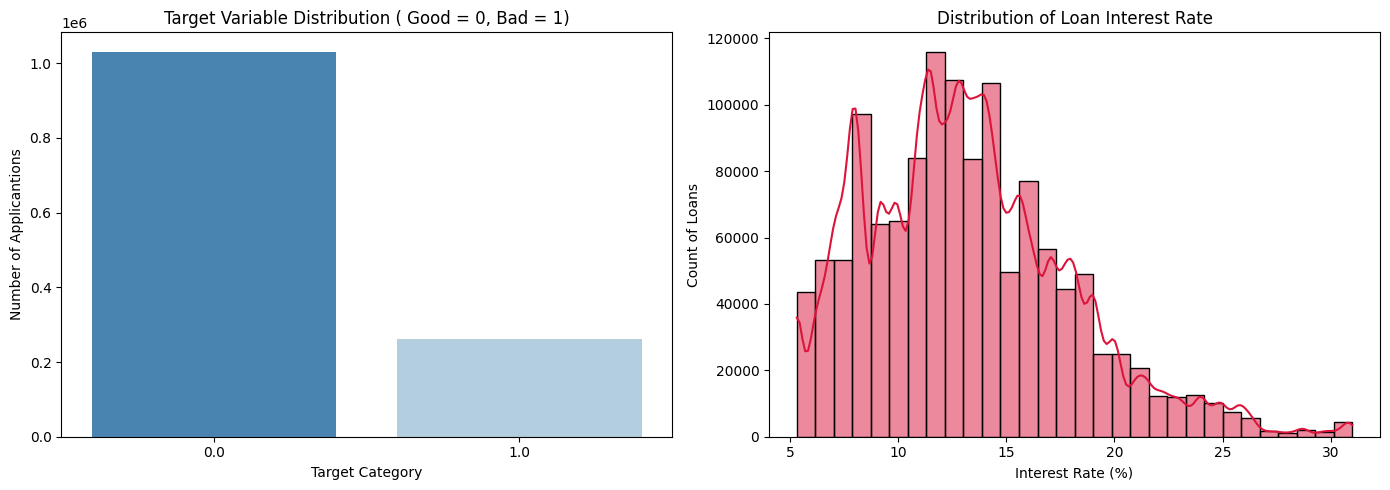

In [83]:
fig, axes = plt.subplots(1, 2, figsize = (14,5))
# Plot 1 : Target Variable Distribution
sns.countplot(x = y_train, ax = axes[0], palette = 'Blues_r')
axes[0].set_title('Target Variable Distribution ( Good = 0, Bad = 1)')
axes[0].set_xlabel('Target Category')
axes[0].set_ylabel('Number of Applicantions')

# Plot 2: Interest Rate Distribution Histogram
sns.histplot(data = X_train_format, x = 'int_rate', bins = 30, kde = True, ax = axes[1], color = 'crimson')
axes[1].set_title('Distribution of Loan Interest Rate')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].set_ylabel('Count of Loans')

plt.tight_layout()
plt.show()



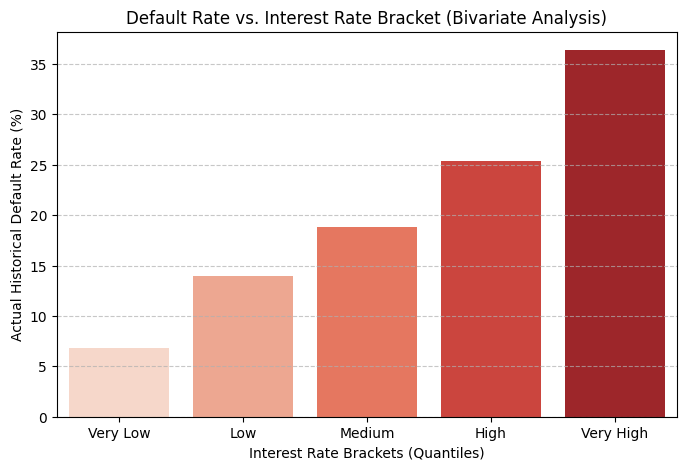

Actual Calculated Default Rates per Bracket
rate_bin
Very Low      6.787890
Low          13.914752
Medium       18.843691
High         25.350519
Very High    36.372188
Name: target, dtype: float64


In [84]:
# Combining training features and targets into a temporary dataframe for analysis
df_temp = X_train_format[['int_rate']].copy()
df_temp['target'] = y_train

# Dividing interest rates into 5 clear sequential and numerical bins 

df_temp['rate_bin'] = pd.qcut(df_temp['int_rate'], q = 5, labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Calculate actual historical default for each interest rate brackets

bivariate_report = df_temp.groupby('rate_bin', observed = False)['target'].mean()*100

#  Plotting the result
plt.figure(figsize=(8,5))
sns.barplot(x = bivariate_report.index, y = bivariate_report.values, hue = bivariate_report.index,  palette = 'Reds')
plt.title('Default Rate vs. Interest Rate Bracket (Bivariate Analysis)')
plt.xlabel('Interest Rate Brackets (Quantiles)')
plt.ylabel('Actual Historical Default Rate (%)')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

print('Actual Calculated Default Rates per Bracket')
print(bivariate_report)

In [85]:
del df_temp, bivariate_report
gc.collect()

6512

## Phase 3: Data Cleaning & Preparation

In [86]:
X_train_cleaner = X_train_format.copy()
X_test_cleaner = X_test_format.copy()

print('---- Phase 3 Analysis Initiated -----')
# Outlier Handling: Winsorization of continuous columns at 1st and 99th percentiles
# Applying this to 'annual_inc' (Annual Income) as the income of the ultra-rich can distort the results

lower_limit = X_train_cleaner['annual_inc'].quantile(0.01)
upper_limit = X_train_cleaner['annual_inc'].quantile(0.99)

# Clipping values outside the boundaries
X_train_cleaner['annual_inc'] = np.clip(X_train_cleaner['annual_inc'], lower_limit, upper_limit)
X_test_cleaner['annual_inc'] = np.clip(X_test_cleaner['annual_inc'], lower_limit, upper_limit)

print(f'Annual Income capped safely between ${lower_limit:,.2f} and ${upper_limit:,.2f}')

# Handling Missing Values 

num_cols = X_train_cleaner.select_dtypes(include = [np.number]).columns
missing_summary = X_train_cleaner[num_cols].isnull().mean()*100
missing_cols = missing_summary[missing_summary > 0].sort_values(ascending = False)

print('\nTop Numerical Columns with Missing Values:')
print(missing_cols.head(5))




---- Phase 3 Analysis Initiated -----
Annual Income capped safely between $18,000.00 and $250,000.00

Top Numerical Columns with Missing Values:
orig_projected_additional_accrued_interest    99.709239
sec_app_mths_since_last_major_derog           99.675874
deferral_term                                 99.556349
hardship_length                               99.556349
sec_app_revol_util                            99.120594
dtype: float64


In [87]:
# Immediately deleting the previous version to free up RAM
del X_train_format, X_test_format
gc.collect()

3356

In [88]:
X_train_imputed = X_train_cleaner.copy()
X_test_imputed = X_test_cleaner.copy()

# Identifying numerical columns that have minor missing rates
minor_missing_summary = X_train_imputed[num_cols].isnull().mean()
standard_impute_cols = minor_missing_summary[(minor_missing_summary > 0) & (minor_missing_summary < 0.05)].index.tolist()
print(standard_impute_cols)

# Defining only true safe column under 5% missingness for median imputation 
safe_median_cols = ['dti', 'revol_util', 'bc_open_to_buy', 'bc_util', 'num_rev_accts', 'percent_bc_gt_75']
print(f'Execcuting median imputaion on {len(safe_median_cols)} randomly omitted features...')

# loop through and applying training medians safely to prevent data leakage 
for cols in safe_median_cols:
    training_median = X_train_imputed[cols].median()
    X_train_imputed[cols] = X_train_imputed[cols].fillna(training_median)
    X_test_imputed[cols] = X_test_imputed[cols].fillna(training_median)
    print(f'Filled blanks in {cols} with {training_median:.2f}')

# Verifying that safe columns are completely clean 
remaining_safe_holes = X_train_imputed[safe_median_cols].isnull().sum().sum()
print(f'Remaining missing cells among median imputed columns {remaining_safe_holes}')

['annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mort_acc', 'mths_since_recent_bc', 'num_bc_sats', 'num_sats', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'total_bal_ex_mort', 'total_bc_limit']
Execcuting median imputaion on 6 randomly omitted features...
Filled blanks in dti with 17.64
Filled blanks in revol_util with 52.80
Filled blanks in bc_open_to_buy with 4560.00
Filled blanks in bc_util with 64.00
Filled blanks in num_rev_accts with 13.00
Filled blanks in percent_bc_gt_75 with 50.00
Remaining missing cells among median imputed columns 0


In [89]:
# Immediately deleting the previous version to free up RAM
del X_train_cleaner, X_test_cleaner
gc.collect()

0

In [90]:
X_train_cat = X_train_imputed.copy()
X_test_cat = X_test_imputed.copy()

# Isolating all text-based columns
cat_cols = X_train_cat.select_dtypes(include = ['object']).columns
print(f'Total categorical columns left to process {len(cat_cols)}\n')

# Summary Report of unique levels and missing values
cat_summary = []
for cols in cat_cols:
    missing_pct = X_train_cat[cols].isnull().mean()*100
    unique_counts = X_train_cat[cols].nunique()
    top_label = X_train_cat[cols].mode()[0]
    cat_summary.append ({
        'Column Name' : cols,
        'Unique Labels' : unique_counts,
        'Missing Rate(%)': missing_pct,
        'Most Common Label': top_label
    })

# Converting to a dataframe 
cat_report_df = pd.DataFrame(cat_summary).sort_values(by = 'Unique Labels', ascending = False)
print(cat_report_df)
        
    

Total categorical columns left to process 3

  Column Name  Unique Labels  Missing Rate(%)   Most Common Label
0   emp_title         372131         6.236506             Teacher
1        desc         124398        90.249663                    
2       title          63151         1.289847  Debt consolidation


In [91]:
X_train_cat_clean = X_train_cat.copy()
X_test_cat_clean = X_test_cat.copy()

# Dropping Invariant Columns ( 1 Unique labels = Zero predditive power)
zero_var_cols = ['hardship_flag', 'pymnt_plan', 'disbursement_method', 'verification_status_joint']
X_train_cat_clean = X_train_cat_clean.drop(columns = zero_var_cols, errors = 'ignore')
X_test_cat_clean = X_test_cat_clean.drop(columns = zero_var_cols, errors = 'ignore')
print(f'Dropped {len(zero_var_cols)} invariant text columns safely')

# Standarizing basic text columns (Removing whitespaces & standardizing casing)
remaining_cat_cols = X_train_cat_clean.select_dtypes(include = ['object']).columns

for col in remaining_cat_cols:
    X_train_cat_clean[col] = X_train_cat_clean[col].fillna('missing').astype(str).str.strip().str.lower()
    X_test_cat_clean[col] = X_test_cat_clean[col].fillna('missing').astype(str).str.strip().str.lower()

# Finding the top 100 most frequent employee title from the training set only
top_100_titles = X_train_cat_clean['emp_title'].value_counts().head(100).index.tolist()

# If the title is not in top 100 and is not 'missing' mapping it to 'other'

X_train_cat_clean['emp_title'] = X_train_cat_clean['emp_title'].apply( lambda x: x if x in top_100_titles else 'other')
X_test_cat_clean['emp_title'] = X_test_cat_clean['emp_title'].apply(lambda x: x if x in top_100_titles else 'other')

print(f'Consolidated "emp_title" from 39112 to: {X_train_cat_clean["emp_title"].nunique()} labels')

print(f'\nTotal remaining features left in dataset matrix: {X_train_cat_clean.shape[1]}')
print(f'\nTop 5 value counts for the consolidated "emp_title":')
print(X_train_cat_clean['emp_title'].value_counts().head(5))
 


Dropped 4 invariant text columns safely
Consolidated "emp_title" from 39112 to: 101 labels

Total remaining features left in dataset matrix: 121

Top 5 value counts for the consolidated "emp_title":
emp_title
other      878684
missing     80562
teacher     25576
manager     24935
owner       15292
Name: count, dtype: int64


In [92]:
# Immediately deleting the previous version to free up RAM
del X_train_cat, X_test_cat
gc.collect()

180

In [93]:
# Final Transitional Audit
leaky_cols = ['debt_settlement_flag', 'settlement_status', 'settlement_date',
    'debt_settlement_flag_date', 'desc', 'title', 'earliest_cr_line',
    'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
    'hardship_reason', 'hardship_loan_status', 'hardship_status', 'hardship_type']

# Permanently dropping from the main pipeline dataframe
X_train_clean = X_train_imputed.drop(columns = leaky_cols, errors = 'ignore')
X_test_clean = X_test_imputed.drop(columns = leaky_cols, errors = 'ignore')

# Overwriting categorical training frame to match perfectly
X_train_cat_clean = X_train_cat_clean.drop(columns = leaky_cols, errors = 'ignore')
X_test_cat_clean = X_test_cat_clean.drop(columns = leaky_cols, errors = 'ignore')

print(f'Final model candidate features remained: {X_train_clean.shape[1]}')



Final model candidate features remained: 111


## Phase 4: Feature Engineering: WoE & IV 

In [94]:
print('--- CUSTOM PURE-PYTHON WoE ENGINE INITIALIZED ---')
df_woe_test = pd.DataFrame({'feature' : X_train_imputed['int_rate'], 'target' : y_train})

#Slicing the continuous interest rate into 10 equal sized risk brackets (deciles)
# duplicates = 'drop' ensures that if certain boundaries overlap, it handles them safely
df_woe_test['bin'] = pd.qcut(df_woe_test['feature'], q = 10, duplicates = 'drop')

# Calculating global baseline counts
total_goods = (df_woe_test['target'] == 0).sum()
total_bads = (df_woe_test['target'] == 1).sum()
print(f'Total global portfolio count -> Total Goods : {total_goods}, Total Bads : {total_bads}\n')

# Grouping our new bins and calculating bin level distribution
bin_summary = df_woe_test.groupby('bin', observed = False)['target'].agg(total_records = 'count', bin_bads = 'sum').reset_index()

# Goods in a bin
bin_summary['bin_goods'] = bin_summary['total_records'] - bin_summary['bin_bads']

# Executing scorecard math formula
# Adding a tiny decimal (0.5) to protect against any accidental division by zero error
bin_summary['pct_goods'] = (bin_summary['bin_goods'] + 0.5) / total_goods
bin_summary['pct_bads'] = (bin_summary['bin_bads'] + 0.5) / total_bads
bin_summary['WoE'] = np.log(bin_summary['pct_goods'] / bin_summary['pct_bads'])
# Calculating Information Value (IV) for the feature
bin_summary['IV'] = (bin_summary['pct_goods'] - bin_summary['pct_bads']) * bin_summary['WoE']
total_iv = bin_summary['IV'].sum()

print(f'Total calculated IV for interest rate: {total_iv:.4f}')
print('\n--- Volatility Risk Profile Matrix ---')
display(bin_summary[['bin', 'total_records', 'bin_goods', 'bin_bads', 'WoE']])



--- CUSTOM PURE-PYTHON WoE ENGINE INITIALIZED ---
Total global portfolio count -> Total Goods : 1031295, Total Bads : 260486

Total calculated IV for interest rate: 0.4514

--- Volatility Risk Profile Matrix ---


,bin,total_records,bin_goods,bin_bads,WoE
0,"(5.319, 7.49]",134749,127997.0,6752.0,1.566076
1,"(7.49, 8.9]",123947,113139.0,10808.0,0.972267
2,"(8.9, 10.49]",130490,114534.0,15956.0,0.594988
3,"(10.49, 11.53]",131685,111160.0,20525.0,0.313286
4,"(11.53, 12.74]",126576,104629.0,21947.0,0.185751
5,"(12.74, 13.98]",129117,102882.0,26235.0,-0.009547
6,"(13.98, 15.22]",129127,98686.0,30441.0,-0.199880
7,"(15.22, 16.99]",135195,98629.0,36566.0,-0.383784
8,"(16.99, 19.24]",122005,82887.0,39118.0,-0.625133
9,"(19.24, 30.99]",128890,76752.0,52138.0,-0.989339


In [95]:
print('---- CUSTOM MASTER VARIABLE SELECTION ENGINE LAUNCHED---')
y_train_array = np.asarray(y_train)
total_goods = (y_train_array == 0).sum()
total_bads = (y_train_array == 1).sum()

iv_records = []

# Extracting column names by type 
all_num_cols = X_train_imputed.select_dtypes(include = [np.number]).columns.tolist()
all_cat_cols = X_train_cat_clean.select_dtypes(include = ['object']).columns.tolist()

# Defining a single function to calculate IV
def calculate_iv_score(df_temp, total_goods, total_bads):
    summary = df_temp.groupby('bin', observed = False)['target'].agg(total = 'count', bads = 'sum').reset_index()
    summary['goods'] = summary['total'] - summary['bads']
    
    # Dropping bins that contain 0 actual records to prevent math distortion
    summary = summary[summary['total'] > 0].copy()
    
    # Applying Haplane/Laplace smoothing (0.5 smoothing) to avoid divide by zero error
    summary['pct_goods'] = (summary['goods'] + 0.5) / total_goods
    summary['pct_bads'] =  (summary['bads'] + 0.5) / total_bads

    #Calculating WoE and IV
    summary['WoE'] = np.log(summary['pct_goods'] / summary['pct_bads'])
    summary['IV_component'] = (summary['pct_goods'] - summary['pct_bads']) * summary['WoE']

    return summary['IV_component'].sum()


---- CUSTOM MASTER VARIABLE SELECTION ENGINE LAUNCHED---


In [96]:
print('--- LOOP A: Processing Numerical Variables ---')
print(f'\nProcessing {len(all_num_cols)} numerical features...')
success_count = 0

for idx, col in enumerate(all_num_cols):
    if X_train_imputed[col].nunique() <= 1:
        print(f' [SKIP]: "{col}" is invariant ( 1 or zero unique values.)')
        continue   
    df_calc = pd.DataFrame({'feature' : X_train_imputed[col].values, 'target': y_train_array})
    
    # Binning continuous data into deciles
    try:
        df_calc['bin'] = pd.qcut(df_calc['feature'], q = 10, duplicates = 'drop')
        iv = calculate_iv_score(df_calc, total_goods, total_bads)
        iv_records.append({'feature': col, 'Variable Type': 'Numerical', 'Information Value (IV)': iv})
        success_count += 1
        
    except Exception as e1:
         # Simple uniform interval cutting if qcut fails entirely on skewed columns
        try:
            df_calc['bin'] = pd.cut(df_calc['feature'], bins = 10, duplicates = 'drop')
            iv = calculate_iv_score(df_calc, total_goods, total_bads)
            iv_records.append({'feature': col, 'Variable Type': 'Numerical', 'Information Value (IV)': iv})
            success_count += 1
        except Exception as e2:
            print(f' [CRASH] "{col}" variable failed both in qcut and cut!')
            print(f' qcut error: {str(e1)}')
            print(f' cut error: {str(e2)}')

print(f'\nNumerical processing complete. Successfully calculted {success_count} / {len(all_num_cols)} columns')

print('\n--- LOOP B: Processing Categorical Variables ---')
print(f'\nProcessing {len(all_cat_cols)} categorical features')

for col in all_cat_cols:
    df_calc = pd.DataFrame({'bin': X_train_cat_clean[col].values, 'target': y_train_array})
    iv = calculate_iv_score(df_calc, total_goods, total_bads)
    iv_records.append({'feature': col, 'Variable Type': 'Categorical', 'Information Value (IV)': iv})
    
# Compiling final master frame
master_iv_df = pd.DataFrame(iv_records)
if not master_iv_df.empty:
    master_iv_df = master_iv_df.sort_values(by = 'Information Value (IV)', ascending = False).reset_index(drop = True)
print('\n---- Feature Selection Output Table -----')
display(master_iv_df.head(20))



--- LOOP A: Processing Numerical Variables ---

Processing 95 numerical features...
 [SKIP]: "policy_code" is invariant ( 1 or zero unique values.)
 [SKIP]: "deferral_term" is invariant ( 1 or zero unique values.)
 [SKIP]: "hardship_length" is invariant ( 1 or zero unique values.)

Numerical processing complete. Successfully calculted 92 / 95 columns

--- LOOP B: Processing Categorical Variables ---

Processing 1 categorical features

---- Feature Selection Output Table -----


,feature,Variable Type,Information Value (IV)
0,settlement_term,Numerical,1.290630
1,settlement_percentage,Numerical,1.259166
2,settlement_amount,Numerical,1.221497
3,int_rate,Numerical,0.451447
4,fico_range_low,Numerical,0.122701
5,fico_range_high,Numerical,0.122701
6,dti,Numerical,0.074317
7,acc_open_past_24mths,Numerical,0.067181
8,bc_open_to_buy,Numerical,0.051535
9,avg_cur_bal,Numerical,0.047812


In [97]:
strategic_drops = [ 
    # Lending Club internal pre-calculated scores (Performance Ceiling)
    'sub_grade', 'int_rate', 'grade',
    # Post-Processing target leakage columns detected
    'settlement_percentage', 'settlement_term', 'settlement_amount',
    # Colinear Duplicates 
    'fico_range_high'
]

# Extracting independent variables that cleared the standard risk hurdle (IV >= 0.02)
# Extracting unique values from master_iv_df and striping the duplicates permanetly

unique_iv_df = master_iv_df.drop_duplicates(subset =['feature']).copy()

final_feature_pool = unique_iv_df[
    (unique_iv_df['Information Value (IV)'] >= 0.02) & 
    (~unique_iv_df['feature'].isin(strategic_drops))
]['feature'].tolist()

print('---- Final Feature Pool -----')
print(f'Total independent predictor sselected {len(final_feature_pool)}')
print(f'Core model features: {final_feature_pool}')

---- Final Feature Pool -----
Total independent predictor sselected 29
Core model features: ['fico_range_low', 'dti', 'acc_open_past_24mths', 'bc_open_to_buy', 'avg_cur_bal', 'num_tl_op_past_12m', 'tot_hi_cred_lim', 'tot_cur_bal', 'total_bc_limit', 'mort_acc', 'loan_amnt', 'all_util', 'mo_sin_rcnt_tl', 'emp_title', 'open_rv_24m', 'num_actv_rev_tl', 'annual_inc', 'num_rev_tl_bal_gt_0', 'installment', 'percent_bc_gt_75', 'bc_util', 'total_rev_hi_lim', 'mo_sin_rcnt_rev_tl_op', 'mths_since_recent_bc', 'revol_util', 'mo_sin_old_rev_tl_op', 'mths_since_recent_inq', 'open_rv_12m', 'inq_last_12m']


## Phase 5: WoE Transformation 

In [98]:
# Re-calculating global baseline
y_train_array = np.asarray(y_train)
total_goods = (y_train_array == 0).sum()
total_bads = (y_train_array == 1).sum()

woe_lookup_dict = {}
X_train_woe = pd.DataFrame(index = X_train_clean.index)
X_test_woe = pd.DataFrame(index = X_test_clean.index)

def extract_woe_map(df_temp):
    summary = df_temp.groupby('bin', observed = False)['target'].agg(total = 'count', bads = 'sum').reset_index()
    summary['goods'] = summary['total'] - summary['bads']
    summary = summary[summary['total'] > 0].copy()

    # Laplace smoothing
    summary['pct_goods'] = (summary['goods'] + 0.5) / total_goods
    summary['pct_bads'] = (summary['bads'] + 0.5) / total_bads
    summary['WoE'] = np.log(summary['pct_goods'] / summary['pct_bads'])
    return dict(zip(summary['bin'], summary['WoE']))


In [99]:
# Looping across the predictor pool
for col in final_feature_pool:
    if col in X_train_clean.columns:
        is_numeric = True
        train_series = X_train_clean[col]
        test_series = X_test_clean[col]
    else:
        is_numeric = False
        train_series = X_train_cat_clean[col]
        test_series = X_test_cat_clean[col]
    
    # Dynamically inspect the true data type
    is_numeric = pd.api.types.is_numeric_dtype(train_series)

    # Generating bin assignments
    df_calc = pd.DataFrame({'feature' : train_series.values, 'target' : y_train_array})
    if is_numeric:
        try:
            # Primary Strategy: Quantile cutting
            df_calc['bin'], bin_edges = pd.qcut(df_calc['feature'], q = 10, duplicates = 'drop', retbins = True)
            # Using the exact training edges to slice the test set defensibly
            test_bins = pd.cut(test_series, bins = bin_edges, include_lowest = True, duplicates = 'drop')
        except Exception:
            # Backup Strategy: Uniform interval cutting
            df_calc['bin'], bin_edges = pd.cut(df_calc['feature'], bins = 10, duplicates = 'drop', retbins = True)
            test_bins = pd.cut(test_series, bins = bin_edges, include_lowest = True, duplicates = 'drop')

        train_bins = df_calc['bin']

    else: 
        # Categorical columns are already mapped natively by category values
        train_bins = train_series
        test_bins = test_series


    # Extracting WoE dictionary
    df_calc['bin'] = train_bins
    col_woe_map = extract_woe_map(df_calc)

    # Saving to master global registry for model
    woe_lookup_dict[col] = col_woe_map

    # Permanently mapping arrays
    X_train_woe[col] = train_bins.map(col_woe_map).values.astype(float)
    X_test_woe[col] = test_bins.map(col_woe_map).values.astype(float)

# Imputing any edge-case, unmapped missing bins in test split with neutral risk (0.0)
X_train_woe.fillna(0.0, inplace = True)
X_test_woe.fillna(0.0, inplace = True)

print(f'Transformed Training Shape : {X_train_woe.shape}')
print(f'Transformed Testing Shape : {X_test_woe.shape}\n')

print(' Sample Check : First five rows of "fico_range_low" metrics :')
print(X_train_woe['fico_range_low'].head())
    

Transformed Training Shape : (1291781, 29)
Transformed Testing Shape : (56318, 29)

 Sample Check : First five rows of "fico_range_low" metrics :
1654414    0.922583
1651664   -0.352784
1654392    0.009610
1654393    0.009610
1654394    0.116169
Name: fico_range_low, dtype: float64


## Phase 6: Model Training   

In [100]:
def train_and_evaluate_scorecard(X_train_woe, y_train, X_test_woe, y_test):
    
    # Training logistic regression model on WoE, transformed features and evaluating predictive power using ROC-AUC and Gini Coeff
    y_train_arr = np.asarray(y_train)
    y_test_arr = np.asarray(y_test)

    log_reg = LogisticRegression(
        max_iter = 1000,
        class_weight = 'balanced',
        random_state = 42,
        solver = 'lbfgs'
    )

    log_reg.fit(X_train_woe, y_train_arr)
    y_pred_proba = log_reg.predict_proba(X_test_woe)[:,1]
    y_pred_class = log_reg.predict(X_test_woe)

    # Calculating credit performance metrics
    auc_score = roc_auc_score(y_test_arr, y_pred_proba)
    gini_score = (auc_score * 2) - 1

    # Displaying performance report
    print('----- PERFORMANCE METRICS -----')
    print(f' ROC_AUC (Area Under Curve): {auc_score:.4%}')
    print(f' Gini Coefficient:           {gini_score:.4%}')

    # Confusion matrix using pandas dataframe mapping 
    print('----- CONFUSION MATRIX -----')
    cm = confusion_matrix(y_test_arr, y_pred_class)
    cm_df = pd.DataFrame(
        cm,
        index = ['Actual Good (0)', 'Actual Bad (1)'],
        columns = ['Predicted Good (0)', 'Predicted Bad (1)']
    )

    print(cm_df)

    print('------ DETAILED CLASSIFICATION REPORT -----')
    print(classification_report(y_test_arr, y_pred_class, target_names = ['Good (0)', 'Bad (1)']))
    return log_reg, y_pred_proba

scorecard_model, test_probabilities = train_and_evaluate_scorecard(X_train_woe, y_train, X_test_woe, y_test)
                   

----- PERFORMANCE METRICS -----
 ROC_AUC (Area Under Curve): 64.9914%
 Gini Coefficient:           29.9828%
----- CONFUSION MATRIX -----
                 Predicted Good (0)  Predicted Bad (1)
Actual Good (0)               29280              18164
Actual Bad (1)                 3588               5286
------ DETAILED CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

    Good (0)       0.89      0.62      0.73     47444
     Bad (1)       0.23      0.60      0.33      8874

    accuracy                           0.61     56318
   macro avg       0.56      0.61      0.53     56318
weighted avg       0.79      0.61      0.67     56318



## Phase 7: Scorecard Scaling  

In [101]:
def build_scorecard_points(model, woe_dict, features, pdo = 20, target_score = 600, target_odds = 50):
    # Transforming logistic regression mathematical coefficients to points based coeffecients
    # Calculating scaling factor and offset
    # Factor = PDO / ln(2)
    factor = pdo / np.log(2)
    # offset = Target Score - (Factor * ln(Target Odds))
    offset = target_score - (factor * np.log(target_odds))

    print('----- Scaling Parameters ----')
    print(f'Points to Double Odds (PDO): {pdo}')
    print(f'Calculated Factor: {factor:.2f}')
    print(f'Calcculated Offset: {offset:2f}')

    # Extracting model architecture
    coefficients = model.coef_[0]
    intercept = model.intercept_[0]
    n_features = len(features)
    
    # Distributing intercept equally across all features
    # As we are predicting log(Bad/Good), thus flipping the sign so that Good Borrower actually yield Higher Point
    base_point = (offset/n_features) - (factor * intercept / n_features)

    # Building Master Scorecard Table
    scorecard_records = []
    print(' Generating bins for all variable points')
    for idx, feature in enumerate(features):
        feature_coef = coefficients[idx]
        feature_woe_map = woe_dict[feature]

        for bin_name, woe_value in feature_woe_map.items():
            # The core scorecard formula
            points = base_point - (factor* feature_coef * woe_value)

            scorecard_records.append({
                'Feature': feature,
                'Bin': bin_name,
                'WoE': woe_value,
                'Coefficients': feature_coef,
                'Points': round(points)
            })

    scorecard_df = pd.DataFrame(scorecard_records)
    print('Scorecard Scaling Complete')
    return scorecard_df

final_scorecard = build_scorecard_points(
    model = scorecard_model,
    woe_dict = woe_lookup_dict,
    features = X_train_woe.columns
)

# Displaying points awarded for FICO Scores.
print('\n----- Final Scorecard Preview: FICO Scores -----')
fico_preview = final_scorecard[final_scorecard['Feature'] == 'fico_range_low']
print(fico_preview[['Bin', 'Points']].sort_values(by = 'Points', ascending = False).to_string(index= False))

            

----- Scaling Parameters ----
Points to Double Odds (PDO): 20
Calculated Factor: 28.85
Calcculated Offset: 487.122876
 Generating bins for all variable points
Scorecard Scaling Complete

----- Final Scorecard Preview: FICO Scores -----
             Bin  Points
  (740.0, 845.0]      33
  (720.0, 740.0]      26
  (705.0, 720.0]      22
  (695.0, 705.0]      19
  (690.0, 695.0]      17
  (680.0, 690.0]      16
  (675.0, 680.0]      14
  (670.0, 675.0]      13
  (665.0, 670.0]      12
(609.999, 665.0]      11


In [102]:
#final_scorecard.to_csv('my_credit_scorecard1.csv', index=False)

## Phase 8: Portfolio Scoring & Business Analysis

Theoretical Maximum Score: 621
Theoretical Minimum Score: 365
Successfully scored 56318 applicants in the test set.
Average Portfolio Score: 493


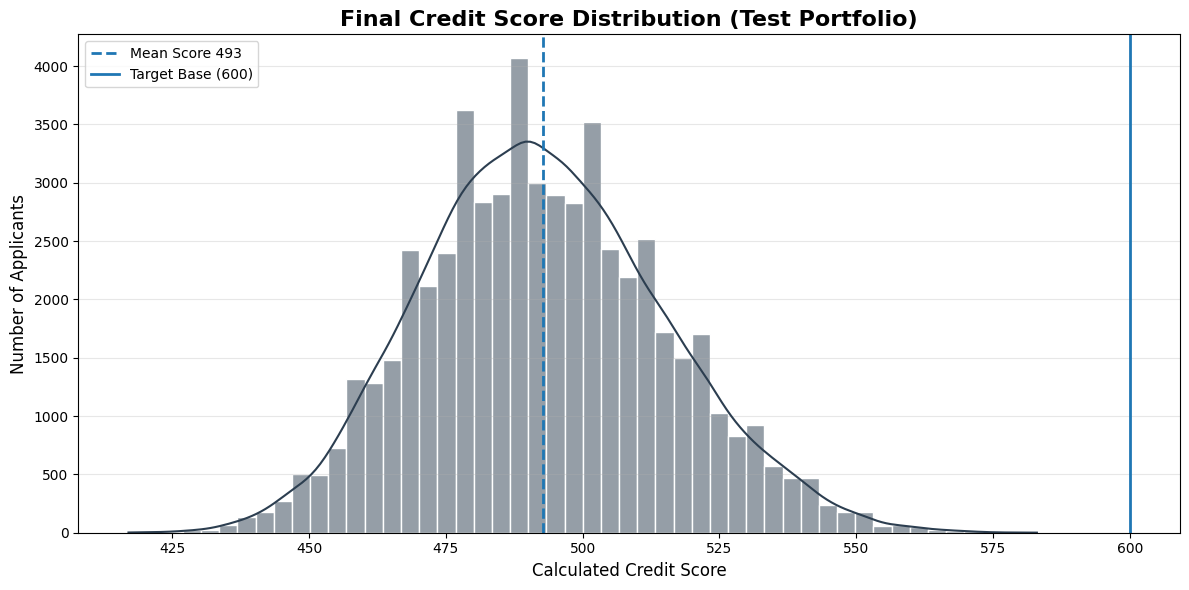

In [103]:
# Calculating Theoretical Max and Min Scores
max_score = final_scorecard.groupby('Feature')['Points'].max().sum()
min_score = final_scorecard.groupby('Feature')['Points'].min().sum()

print(f'Theoretical Maximum Score: {max_score}')
print(f'Theoretical Minimum Score: {min_score}')

# Scoring Test Applicants
# Instead of the loop, using a mathematical formula shortcut to score instantly
# Final Score = Offset - (Factor * Log_Odds_Bad)
# Reloading parameters
pdo = 20
target_score = 600
target_odds = 50
factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))

# Raw Log_Odds of being a Bad Loan
log_odds_bad = scorecard_model.decision_function(X_test_woe)

# Calculating test score for all test applicants
test_scores = offset - (factor * log_odds_bad)
test_scores = np.round(test_scores)

print(f'Successfully scored {len(test_scores):} applicants in the test set.')
print(f'Average Portfolio Score: {test_scores.mean():.0f}')

# Plotting the Credit Distribution (Bell Curve)
plt.figure(figsize = (12,6))

sns.histplot(test_scores, bins = 50, kde = True, color = '#2c3e50', edgecolor = 'white')

# Adding vertical benchmark lines
plt.axvline(test_scores.mean(), linestyle = '--', linewidth = 2, label = f'Mean Score {test_scores.mean():.0f}')
plt.axvline(600, linestyle = '-', linewidth = 2, label = 'Target Base (600)')

plt.title('Final Credit Score Distribution (Test Portfolio)', fontsize = 16, fontweight = 'bold')
plt.xlabel('Calculated Credit Score', fontsize = 12)
plt.ylabel('Number of Applicants', fontsize = 12)
plt.legend()
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()


,Score Band,Applicants,Goods,Bads,Band Bad Rate (%),Cumul. Approval (%),Portfolio Bad Rate (%)
0,"(605.0, 621.0]",0,0.0,0.0,—,0.00,—
1,"(575.0, 605.0]",3,3.0,0.0,0.0,0.01,0.0
2,"(545.0, 575.0]",647,628.0,19.0,2.94,1.15,2.92
3,"(515.0, 545.0]",8193,7649.0,544.0,6.64,15.70,6.37
4,"(485.0, 515.0]",25625,22343.0,3282.0,12.81,61.20,11.16
5,"(455.0, 485.0]",19670,15319.0,4351.0,22.12,96.13,15.14
6,"(425.0, 455.0]",2168,1496.0,672.0,31.0,99.98,15.75
7,"(395.0, 425.0]",12,6.0,6.0,50.0,100.00,15.76
8,"(364.999, 395.0]",0,0.0,0.0,—,100.00,15.76


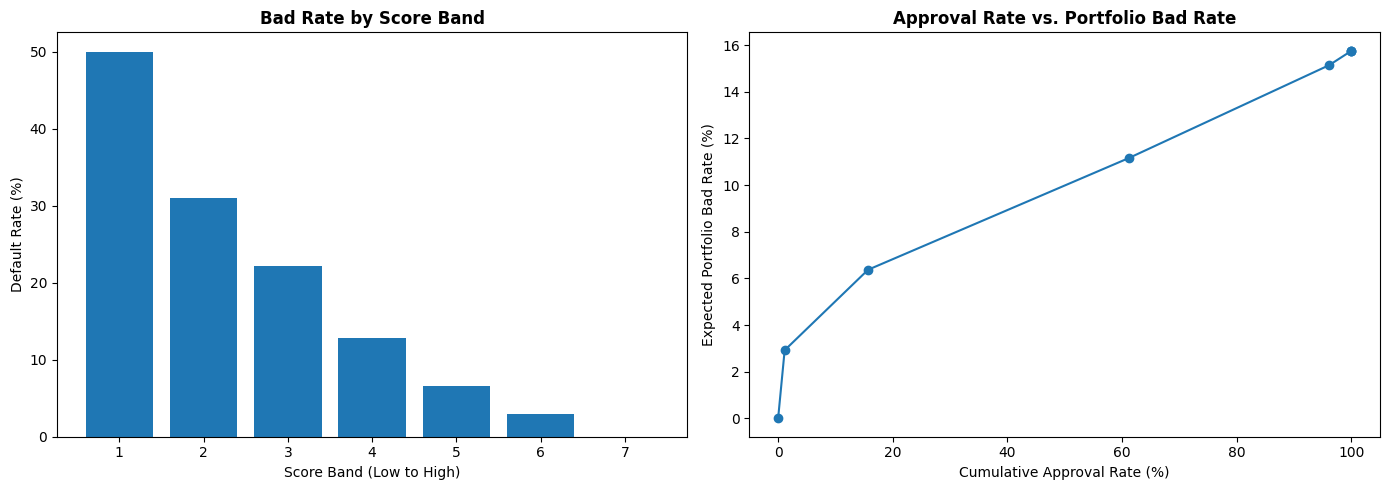

In [104]:
# Scoreband Table 
# Business Question: If above score x everyone is approved what will be the approval rate and expected bad rate
# Combining score and actual outcome
score_band_df = pd.DataFrame({
    'score' : test_scores,
    'actual' : np.asarray(y_test)
})

# Defining score bands across full range
band_boundaries = list(range(min_score, max_score, 30))
band_boundaries.append(max_score)

score_band_df['score_band'] = pd.cut(
    score_band_df['score'],
    bins = band_boundaries,
    include_lowest = True,
    right = True
)

# Caluating within band statistics
band_summary = score_band_df.groupby('score_band', observed = False)['actual'].agg(Applicants = 'count', Bads = 'sum').reset_index()

band_summary['Goods'] = band_summary['Applicants'] - band_summary['Bads']
band_summary['Band_Bad_Rate_%'] = (( band_summary['Bads'] / band_summary['Applicants'])*100).round(2)

# Sorting from highest to lowest ( Best borrower at top and riskiest at bottom)
band_summary = band_summary.sort_values('score_band', ascending = False).reset_index(drop = True)

# Calculating cummulative columns
total_applicants = band_summary['Applicants'].sum()
band_summary['Cumul_Approved_%'] = ((band_summary['Applicants'].cumsum() / total_applicants)*100).round(2)
band_summary['Portfolio_Bad_Rate_%'] = ((band_summary['Bads'].cumsum() / band_summary['Applicants'].cumsum())*100).round(2)

display_table = band_summary[['score_band', 'Applicants', 'Goods', 'Bads', 'Band_Bad_Rate_%', 'Cumul_Approved_%', 'Portfolio_Bad_Rate_%']]
display_table.columns = [ 'Score Band', 'Applicants', 'Goods', 'Bads','Band Bad Rate (%)', 'Cumul. Approval (%)', 'Portfolio Bad Rate (%)']

display_table['Band Bad Rate (%)'] = display_table['Band Bad Rate (%)'].fillna('—')
display_table['Portfolio Bad Rate (%)'] = display_table['Portfolio Bad Rate (%)'].fillna('—')

display(display_table)

# Visualizing bad rate by score band 
fig, axes = plt.subplots(1,2, figsize = (14,5))

# Chart 1: Within Band Bad Rate
plot_data = band_summary.sort_values('score_band', ascending = True)
axes[0].bar(range(len(plot_data)), plot_data['Band_Bad_Rate_%'])
axes[0].set_title('Bad Rate by Score Band', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score Band (Low to High)')
axes[0].set_ylabel('Default Rate (%)')

# Chart2 : Approval rate vs. portfolio bad rate trade-off
# X axis = cumulative approval %, Y axis = portfolio bad rate %
plot_data_2 = band_summary.sort_values('score_band', ascending = False)
axes[1].plot(plot_data_2['Cumul_Approved_%'], plot_data_2['Portfolio_Bad_Rate_%'], marker = 'o')
axes[1].set_title('Approval Rate vs. Portfolio Bad Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cumulative Approval Rate (%)')
axes[1].set_ylabel('Expected Portfolio Bad Rate (%)')

plt.tight_layout()
plt.show()


## Phase 9: Institutional Validation 

In [105]:
print('------ WOE Monotonicity Audit ------')
# Checking if WoE values increase or decrease consistently across bins
non_monotonic_features = []
monotonic_count = 0
categorical_count = 0
for col in final_feature_pool:
    woe_map = woe_lookup_dict[col]
    bins =list(woe_map.keys())

    if len(bins) == 0:
        continue
    # Numeric features have  pandas Interval Object as bin keys
    # Categorical variables have no natural order, so skipping them
    if hasattr(bins[0], 'left'):
        # Sorting bins by their left boundary so going from low to high
        sorted_pairs = sorted(woe_map.items(), key = lambda x: x[0].left)
        woe_values = [woe for _, woe in sorted_pairs]

        is_increasing = all(woe_values[i] <= woe_values[i+1] for i in range(len(woe_values) - 1))
        is_decreasing = all(woe_values[i] >= woe_values[i+1] for i in range(len(woe_values) - 1))
        is_monotonic = is_increasing or is_decreasing


        direction = '(increasing)' if is_increasing else '(decreasing)' if is_decreasing else '(no consistent direction)'
        status = 'PASS' if is_monotonic else 'FAIL'

        print(f'{col:40s} {direction}, {status}')

        if is_monotonic:
            monotonic_count += 1

        else:
            non_monotonic_features.append(col)
    else:
        categorical_count += 1

numeric_total = len(final_feature_pool) - categorical_count

print('\n------- SUMMARY -------')
print(f'Numeric features checked: {numeric_total}')
print(f'Monotonic (PASS): {monotonic_count}')
print(f'Non Monotonic (Needs Review): {len(non_monotonic_features)}')
print(f'Categorical (SKIPPED): {categorical_count}')

if non_monotonic_features:
    print(f'\nFeatures to Review Manually: ')
    for f in non_monotonic_features:
        woe_map = woe_lookup_dict[f]
        sorted_pairs = sorted(woe_map.items(), key = lambda x: x[0].left)
        print(f'\n {f}: ')
        for bin_label, woe_val in sorted_pairs:
            print(f' {str(bin_label):40s} WoE = {woe_val:+.4f}')
        



------ WOE Monotonicity Audit ------
fico_range_low                           (increasing), PASS
dti                                      (decreasing), PASS
acc_open_past_24mths                     (decreasing), PASS
bc_open_to_buy                           (no consistent direction), FAIL
avg_cur_bal                              (no consistent direction), FAIL
num_tl_op_past_12m                       (decreasing), PASS
tot_hi_cred_lim                          (no consistent direction), FAIL
tot_cur_bal                              (no consistent direction), FAIL
total_bc_limit                           (increasing), PASS
mort_acc                                 (increasing), PASS
loan_amnt                                (no consistent direction), FAIL
all_util                                 (decreasing), PASS
mo_sin_rcnt_tl                           (increasing), PASS
open_rv_24m                              (decreasing), PASS
num_actv_rev_tl                          (decreasing), PAS

In [106]:
print('------- KS Statistics -------')
# separating predicted probability with actual outcome
bad_scores = test_probabilities[np.asarray(y_test == 1)]
good_scores = test_probabilities[np.asarray(y_test == 0)]

# KS: Maximum separation between two cummulative distribution 
ks_stat, _ = ks_2samp(bad_scores, good_scores)

print(f'KS Statistics: {ks_stat*100:.2f}')


------- KS Statistics -------
KS Statistics: 21.78
